# 4.4 - LwF

Freeze a copy of the model before each task and keep the old-class outputs close to
what that copy predicts.

Memory: 0 bytes of data, only a copy of the weights.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "xx"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

In [5]:
# BASE
cfg.OUTPUT_ROOT = cfg.BASE_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.SELECTED_CLASSES)

# TASK 1
cfg.OUTPUT_ROOT = cfg.TASK1_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT = cfg.TASK2_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_2)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_base
Classes: 10 | Limit: Full

Processing split: train


  PlayingTabla [train]:   0%|          | 0/83 [00:00<?, ?it/s]


Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_base

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_task1
Classes: 10 | Limit: Full

Processing split: train


...


Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_task2
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task2


In [6]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [7]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling']


In [8]:
# The cache fixes the label space, so it is built once here for all tasks.
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BandMarching': 15, 'BlowDryHair': 16, 'BlowingCandles': 17, 'BodyWeightSquats': 18, 'Bowling': 19, 'BoxingPunchingBag': 20, 'BoxingSpeedBag': 21, 'BrushingTeeth': 22, 'CliffDiving': 23, 'CricketBowling': 24, 'CricketShot': 25, 'CuttingInKitchen': 26, 'FieldHockeyPenalty': 27, 'Haircut': 28, 'SoccerPenalty': 29}


## **Create Loaders**

In [9]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)
check_cache_labels(META, ALL_CLASSES_LIST)

TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_ROOTS   = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
TASK_NAMES   = ["Base", "Task1", "Task2"]

base_test_loader  = emb_loaders(CACHE, [0], "test")[1]
task1_test_loader = emb_loaders(CACHE, [1], "test")[1]
task2_test_loader = emb_loaders(CACHE, [2], "test")[1]

combined_test_loader  = emb_loaders(CACHE, [0, 1], "test")[1]
combined_test_loader2 = emb_loaders(CACHE, [0, 1, 2], "test")[1]

base_train,  base_y   = task_split(CACHE, 0, "train")
base_val,    base_vy  = task_split(CACHE, 0, "val")
task1_train, task1_y  = task_split(CACHE, 1, "train")
task1_val,   task1_vy = task_split(CACHE, 1, "val")
task2_train, task2_y  = task_split(CACHE, 2, "train")
task2_val,   task2_vy = task_split(CACHE, 2, "val")

print(f"base  test {len(base_test_loader.dataset)}")
print(f"task1 test {len(task1_test_loader.dataset)}")
print(f"task2 test {len(task2_test_loader.dataset)}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
base  test 212
task1 test 217
task2 test 226


## **Upload Model**

In [10]:
ARM_KEY  = "lwf"
ARM_NAME = "LwF"
KD_LAMBDA, KD_T = cfg.LAMBDA_DISTILL, 5.0
ARM_CONFIG = {"mechanism": "lwf", "kd_lambda": KD_LAMBDA, "kd_T": KD_T}

CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS = 15, 5e-4, 0.03, 32, 0.10

head_base = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
)

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt


In [11]:
teacher1 = snapshot_teacher(head_base)

head_task1 = expand_head(copy.deepcopy(head_base), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1))
model_task1 = ModelWrapper(head_task1).to(device)

In [12]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9009  Loss=0.9683
  task1_only       -> Acc=0.0184  Loss=3.1715
  combined_t1      -> Acc=0.4545  Loss=2.0827


In [13]:
print(f"head_task1 classifier: in={head_task1.classifier.in_features}  out={head_task1.classifier.out_features}")

head_task1 classifier: in=256  out=20


## **Task One**

In [14]:
set_seed(cfg.SEED)

head_task1, train_task1 = train_task(
    head_task1, task1_train, task1_y, task1_val, task1_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    teacher=teacher1, kd_lambda=KD_LAMBDA, kd_T=KD_T,
    num_old_classes=len(cfg.SELECTED_CLASSES),
    tag=ARM_KEY,
)
model_task1 = ModelWrapper(head_task1).to(device)

Epoch [1/15] | Train Acc: 0.6474 Loss: 1.5737 | Val Acc: 0.7908 Loss: 0.8005
  [lwf] ep 01/15 | CE 1.5737 | KD 0.2423
Epoch [2/15] | Train Acc: 0.9466 Loss: 0.8124 | Val Acc: 0.8497 Loss: 0.6239
Epoch [3/15] | Train Acc: 0.9840 Loss: 0.7120 | Val Acc: 0.8627 Loss: 0.6186
Epoch [4/15] | Train Acc: 0.9947 Loss: 0.6729 | Val Acc: 0.8693 Loss: 0.5922
Epoch [5/15] | Train Acc: 1.0000 Loss: 0.6477 | Val Acc: 0.8235 Loss: 0.6835
Epoch [6/15] | Train Acc: 1.0000 Loss: 0.6440 | Val Acc: 0.8758 Loss: 0.6169
Epoch [7/15] | Train Acc: 1.0000 Loss: 0.6379 | Val Acc: 0.8497 Loss: 0.6628
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.6354 | Val Acc: 0.8562 Loss: 0.6349
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.6331 | Val Acc: 0.8497 Loss: 0.6584
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.6325 | Val Acc: 0.8562 Loss: 0.6381
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.6325 | Val Acc: 0.8497 Loss: 0.6561
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.6310 | Val Acc: 0.8562 Loss: 0.6375
Epoch [13/15] | Train Acc: 1.000

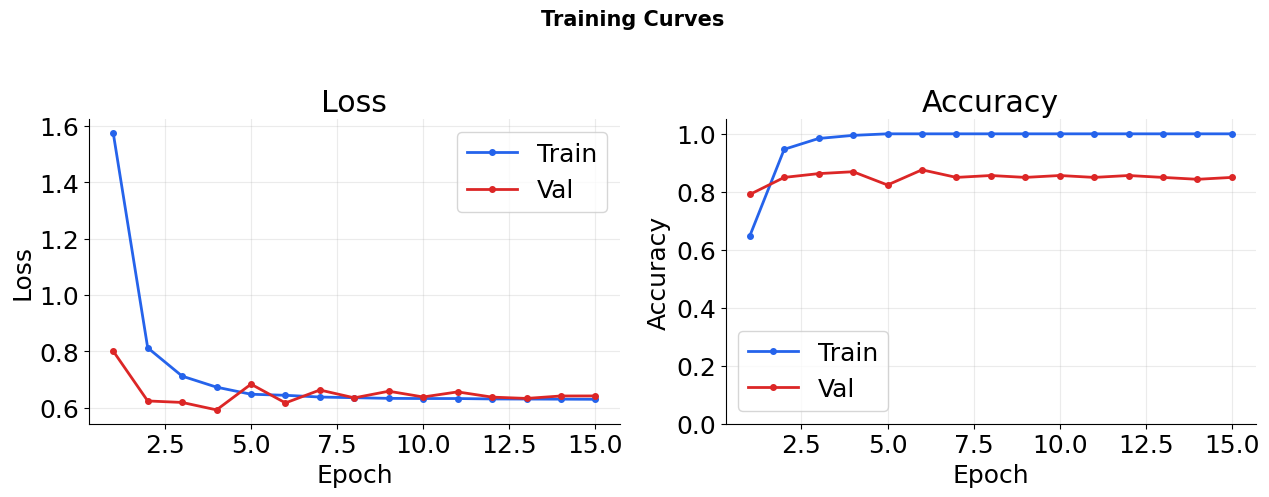

In [15]:
plot_training_results(train_task1)

In [16]:
results_after_t1 = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.1934  Loss=2.1655
  task1_only       -> Acc=0.9171  Loss=0.4305
  combined_t1      -> Acc=0.5594  Loss=1.2879


Running Inference on Test Set...


Test Accuracy: 0.5594


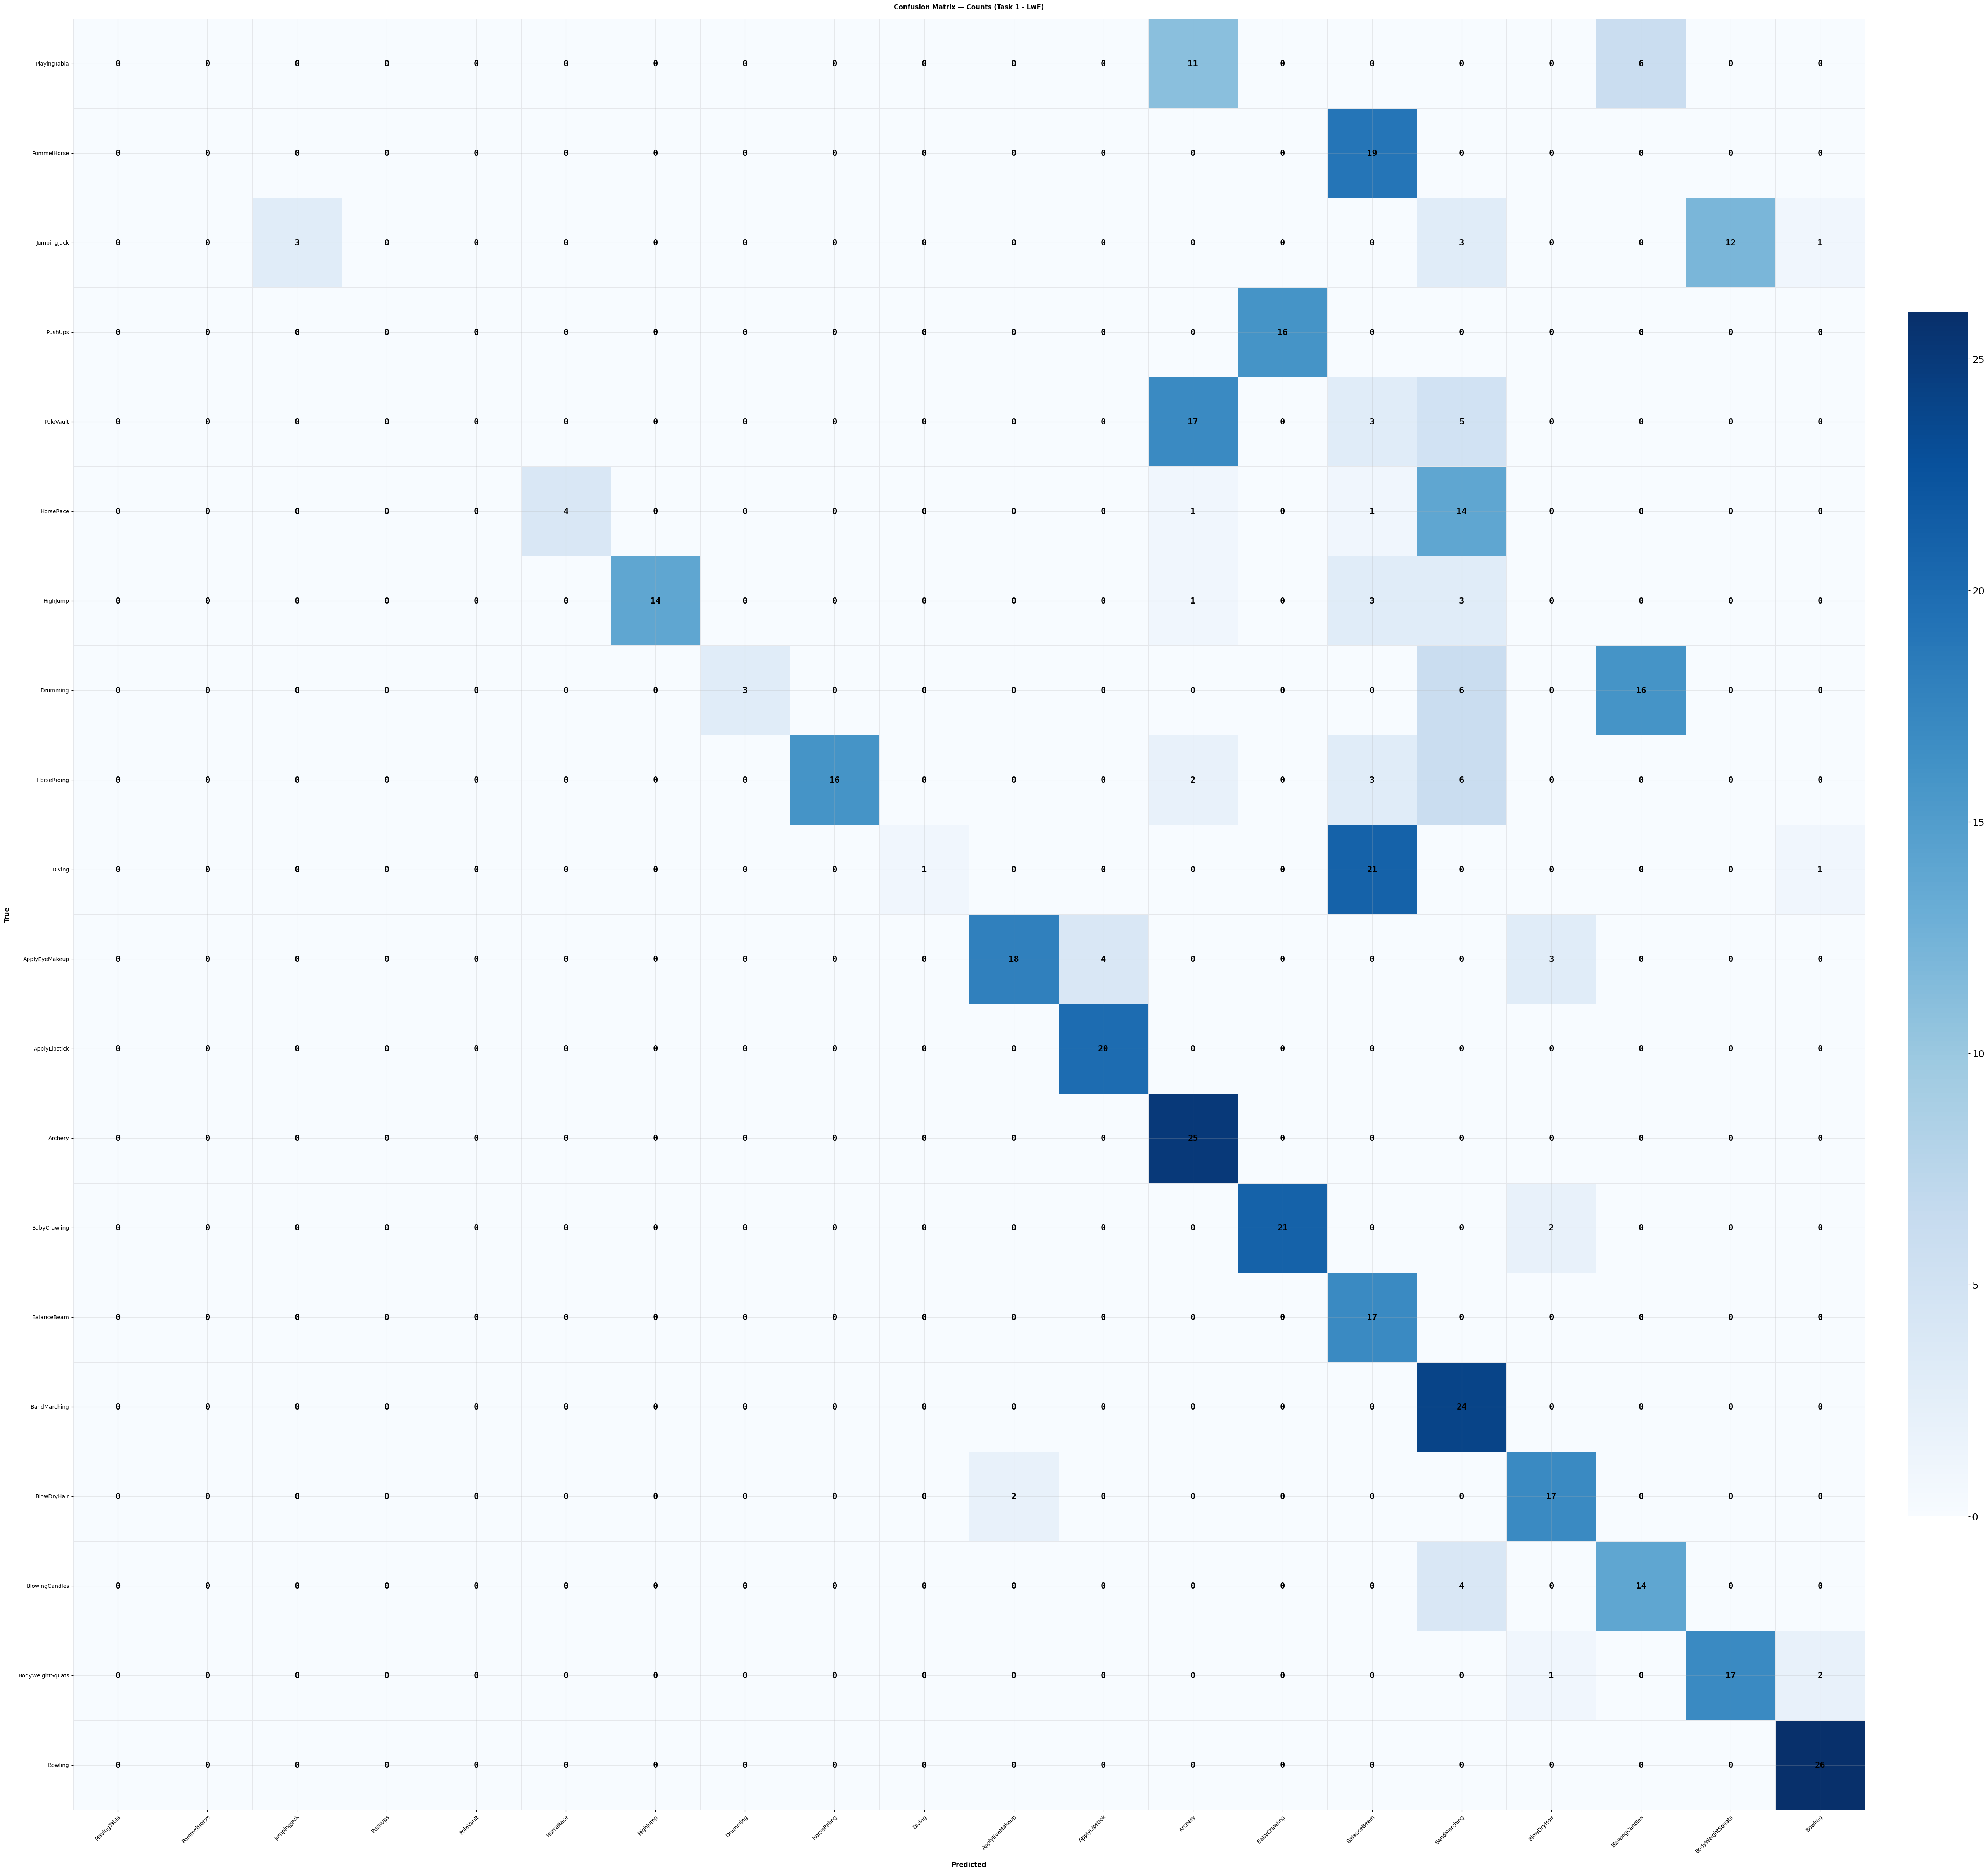

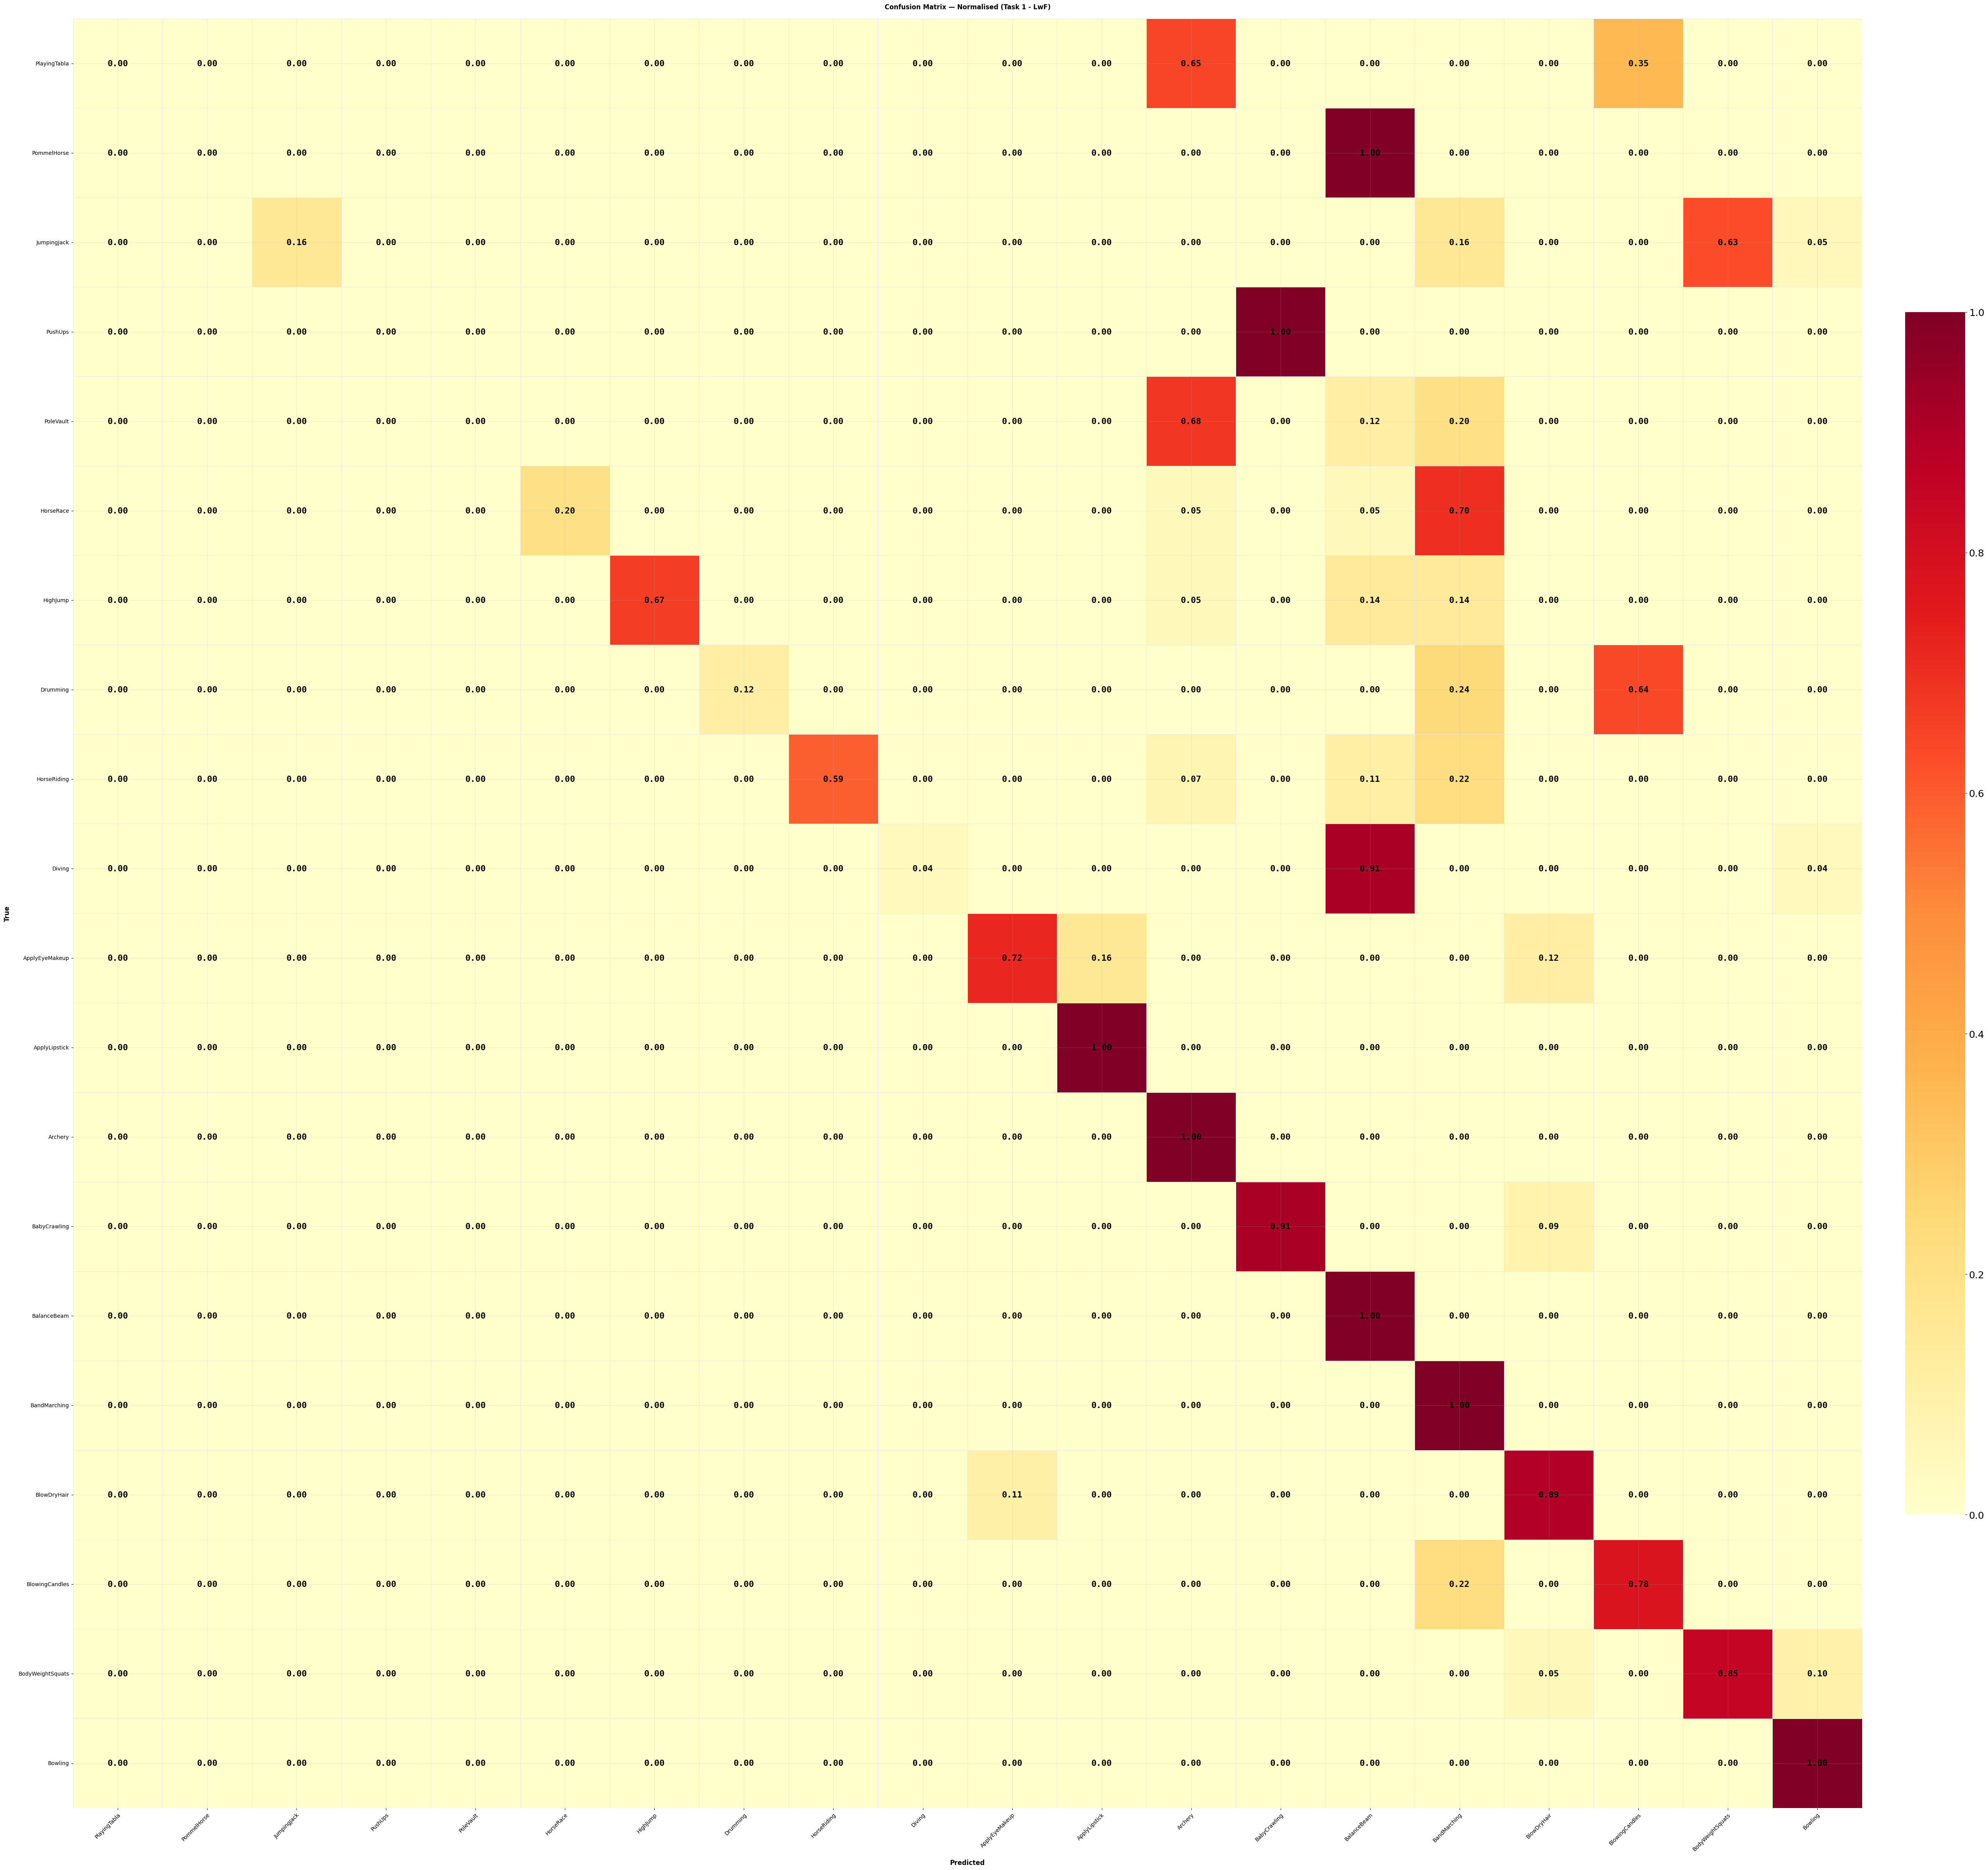

In [17]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 1 - {ARM_NAME}",
)

In [18]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)),
)


METRICS FOR 20 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.5594
  Precision : 0.6216
  Recall    : 0.5594
  F1-Score  : 0.4851

PER-CLASS REPORT 
                  precision    recall  f1-score   support

    PlayingTabla       0.00      0.00      0.00        17
     PommelHorse       0.00      0.00      0.00        19
     JumpingJack       1.00      0.16      0.27        19
         PushUps       0.00      0.00      0.00        16
       PoleVault       0.00      0.00      0.00        25
       HorseRace       1.00      0.20      0.33        20
        HighJump       1.00      0.67      0.80        21
        Drumming       1.00      0.12      0.21        25
     HorseRiding       1.00      0.59      0.74        27
          Diving       1.00      0.04      0.08        23
  ApplyEyeMakeup       0.90      0.72      0.80        25
   ApplyLipstick       0.83      1.00      0.91        20
         Archery       0.44      1.00      0.61        25
    BabyCrawling       0.57      

## **Task 2**

In [19]:
teacher2 = snapshot_teacher(head_task1)


head_task2 = expand_head(head_task1, len(ALL_CLASSES_LIST))
model_task2 = ModelWrapper(head_task2).to(device)

In [20]:
results_baseline = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.1934  Loss=2.3395
  task1_only       -> Acc=0.9171  Loss=0.5256
  task2_only       -> Acc=0.0000  Loss=4.3948
  combined_t1      -> Acc=0.5594  Loss=1.4219
  combined_t2      -> Acc=0.3664  Loss=2.4477


In [21]:
set_seed(cfg.SEED)

head_task2, train_task2 = train_task(
    head_task2, task2_train, task2_y, task2_val, task2_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    teacher=teacher2, kd_lambda=KD_LAMBDA, kd_T=KD_T,
    num_old_classes=len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    tag=ARM_KEY,
)
model_task2 = ModelWrapper(head_task2).to(device)

Epoch [1/15] | Train Acc: 0.6398 Loss: 1.7546 | Val Acc: 0.7342 Loss: 0.7316
  [lwf] ep 01/15 | CE 1.7546 | KD 0.2939
Epoch [2/15] | Train Acc: 0.9395 Loss: 0.9190 | Val Acc: 0.7975 Loss: 0.5712
Epoch [3/15] | Train Acc: 0.9859 Loss: 0.7969 | Val Acc: 0.8418 Loss: 0.5906
Epoch [4/15] | Train Acc: 0.9950 Loss: 0.7555 | Val Acc: 0.8038 Loss: 0.6687
Epoch [5/15] | Train Acc: 0.9990 Loss: 0.7368 | Val Acc: 0.8418 Loss: 0.6739
Epoch [6/15] | Train Acc: 1.0000 Loss: 0.7275 | Val Acc: 0.7911 Loss: 0.6871
Epoch [7/15] | Train Acc: 1.0000 Loss: 0.7236 | Val Acc: 0.8228 Loss: 0.6645
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.7197 | Val Acc: 0.8165 Loss: 0.6859
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.7172 | Val Acc: 0.8038 Loss: 0.7339
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.7176 | Val Acc: 0.7911 Loss: 0.7031
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.7162 | Val Acc: 0.7975 Loss: 0.7078
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.7158 | Val Acc: 0.7848 Loss: 0.7113
Epoch [13/15] | Train Acc: 1.000

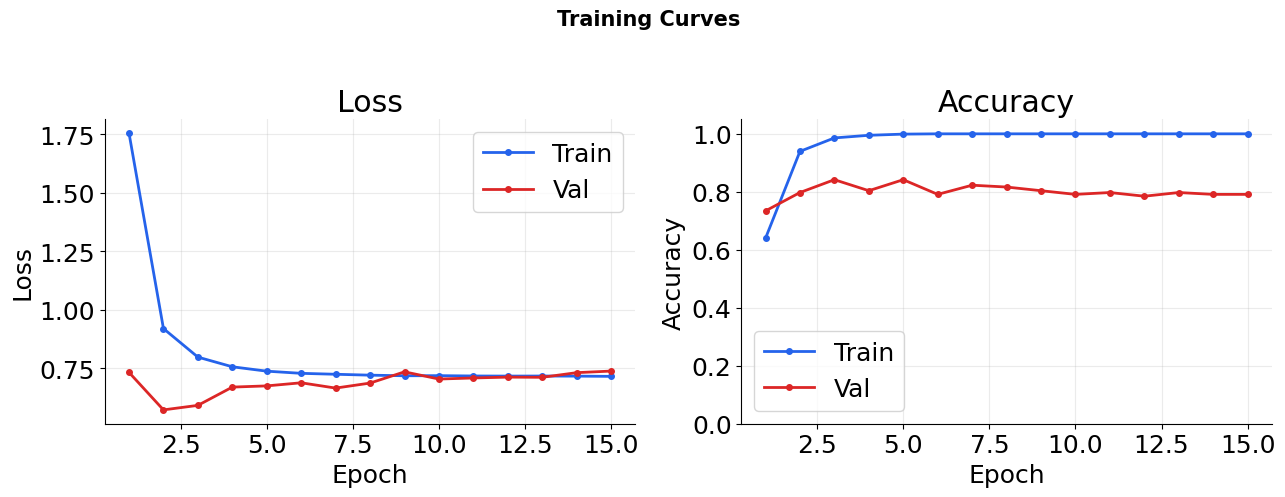

In [22]:
plot_training_results(train_task2)

In [23]:
results_after_t2 = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.0094  Loss=3.2106
  task1_only       -> Acc=0.4654  Loss=1.5470
  task2_only       -> Acc=0.8451  Loss=0.6721
  combined_t1      -> Acc=0.2401  Loss=2.3691
  combined_t2      -> Acc=0.4489  Loss=1.7836


Running Inference on Test Set...


Test Accuracy: 0.4489


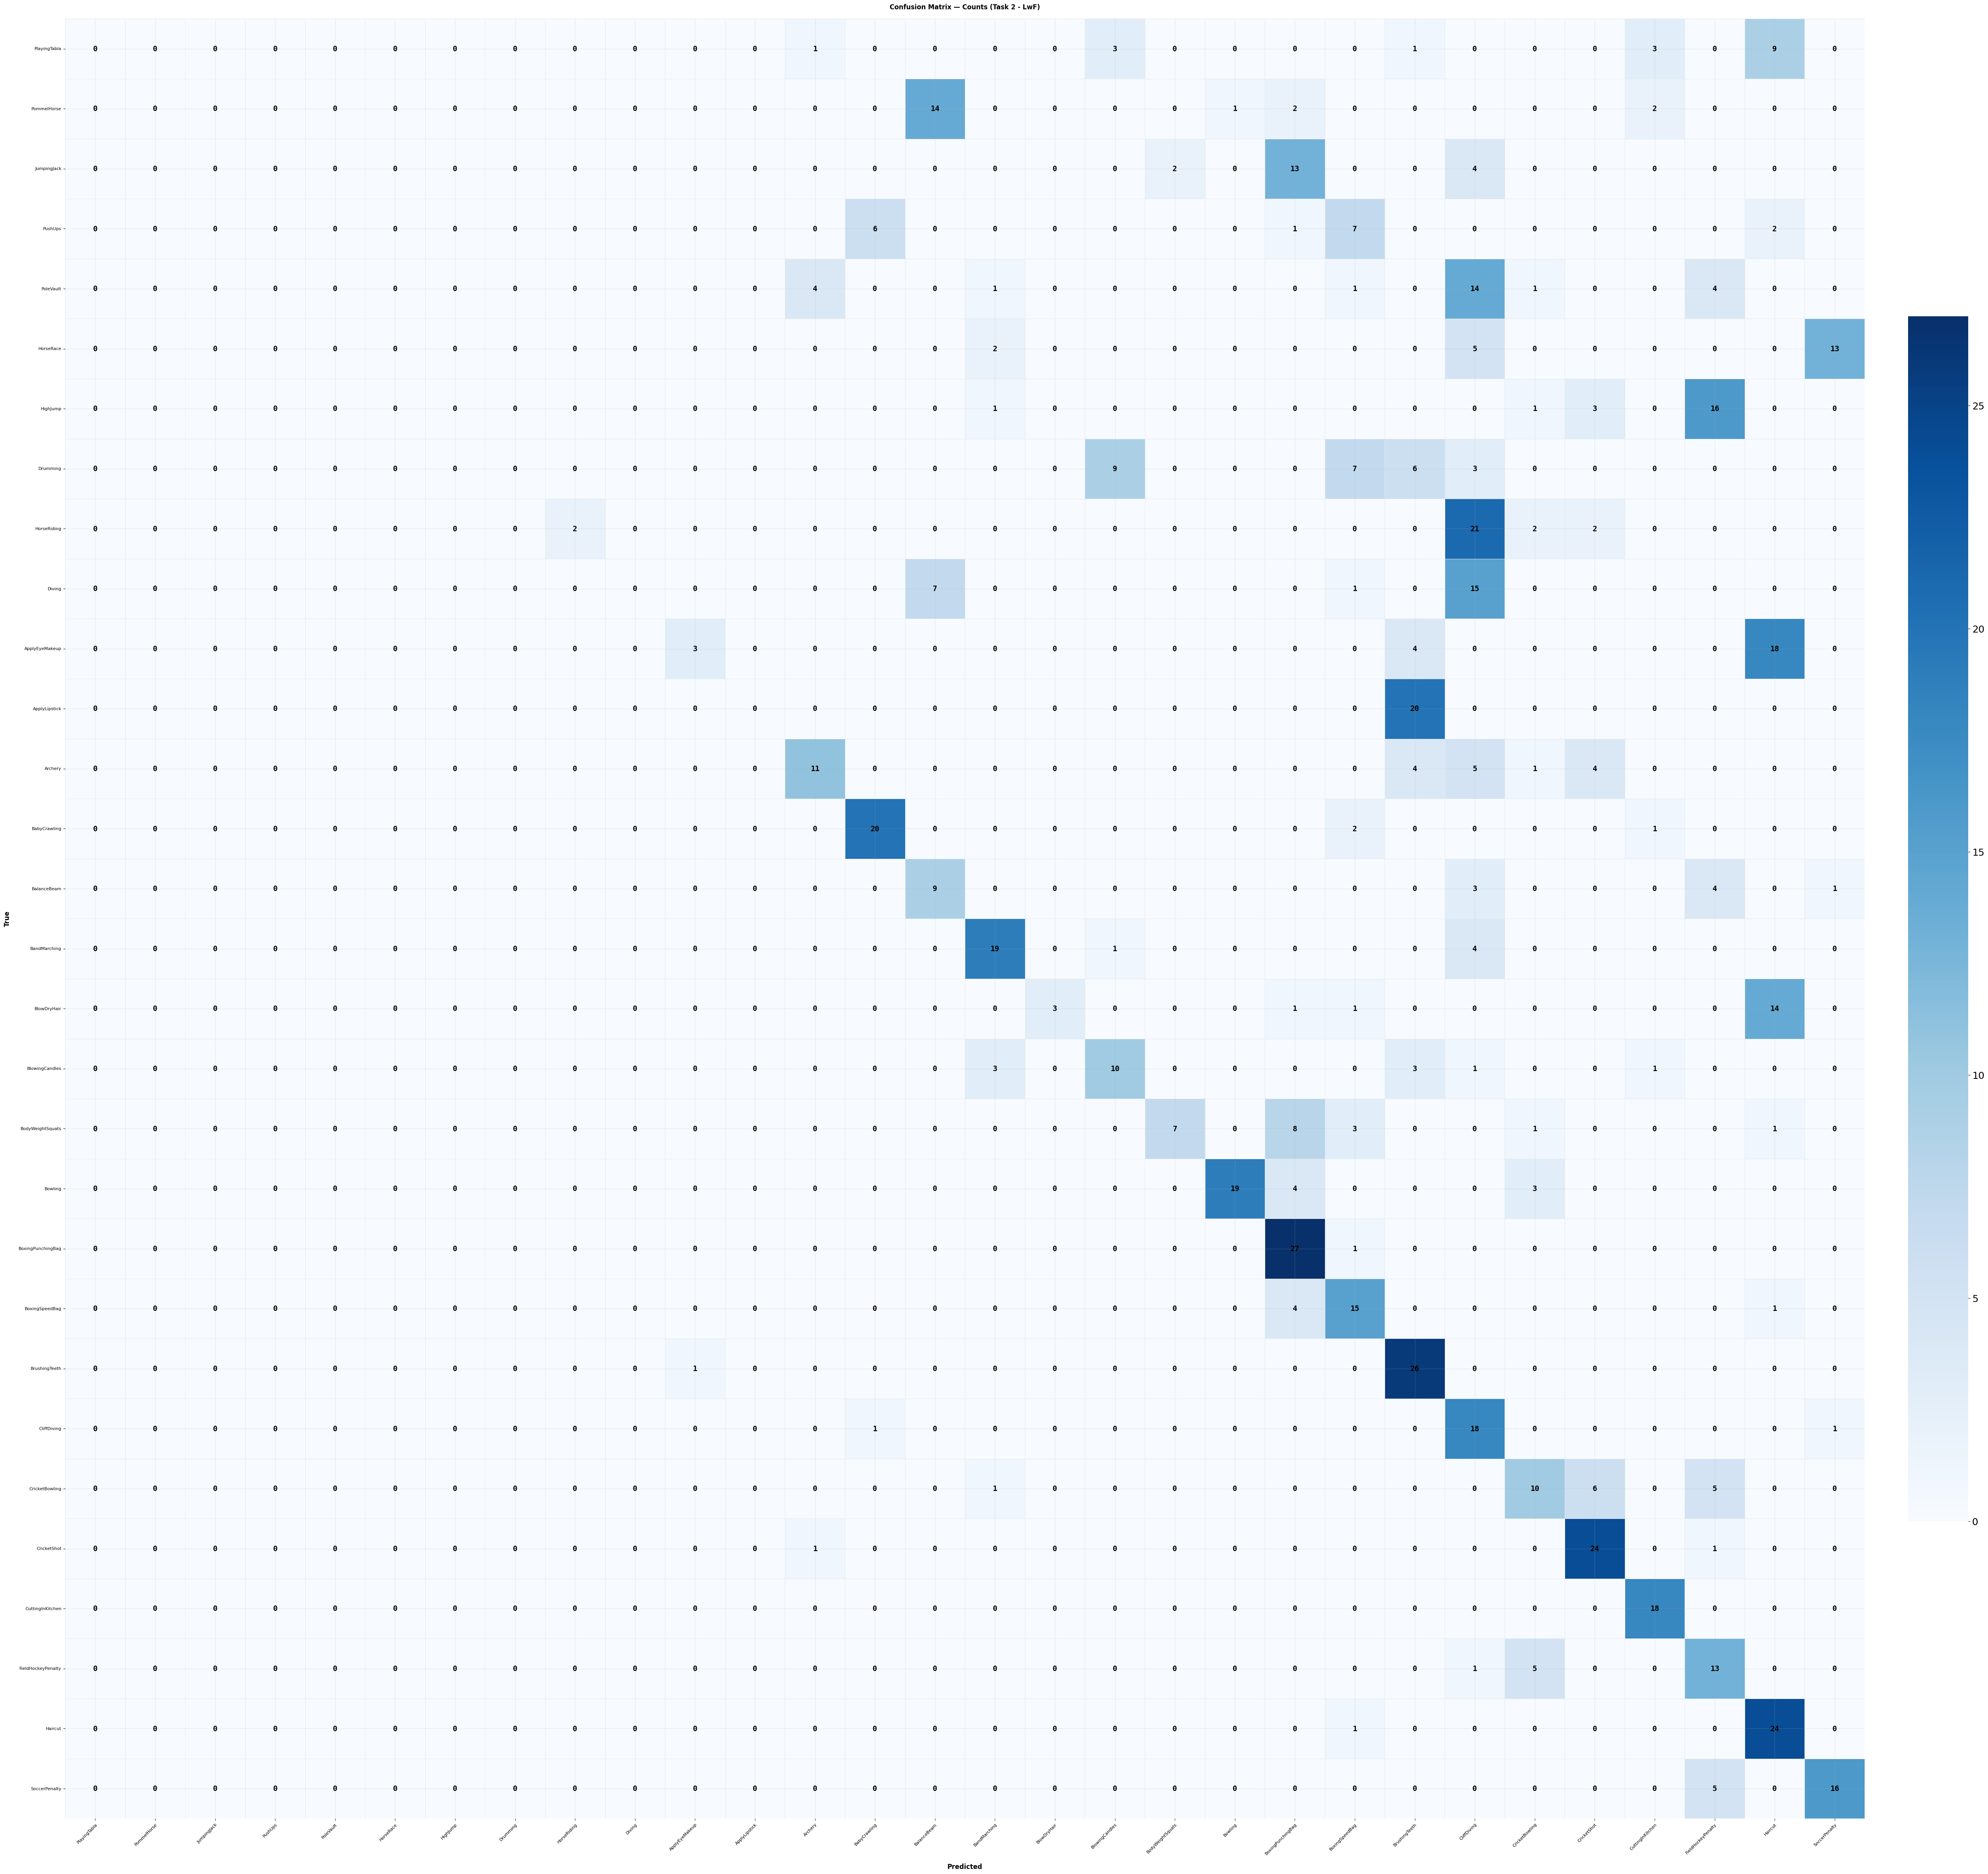

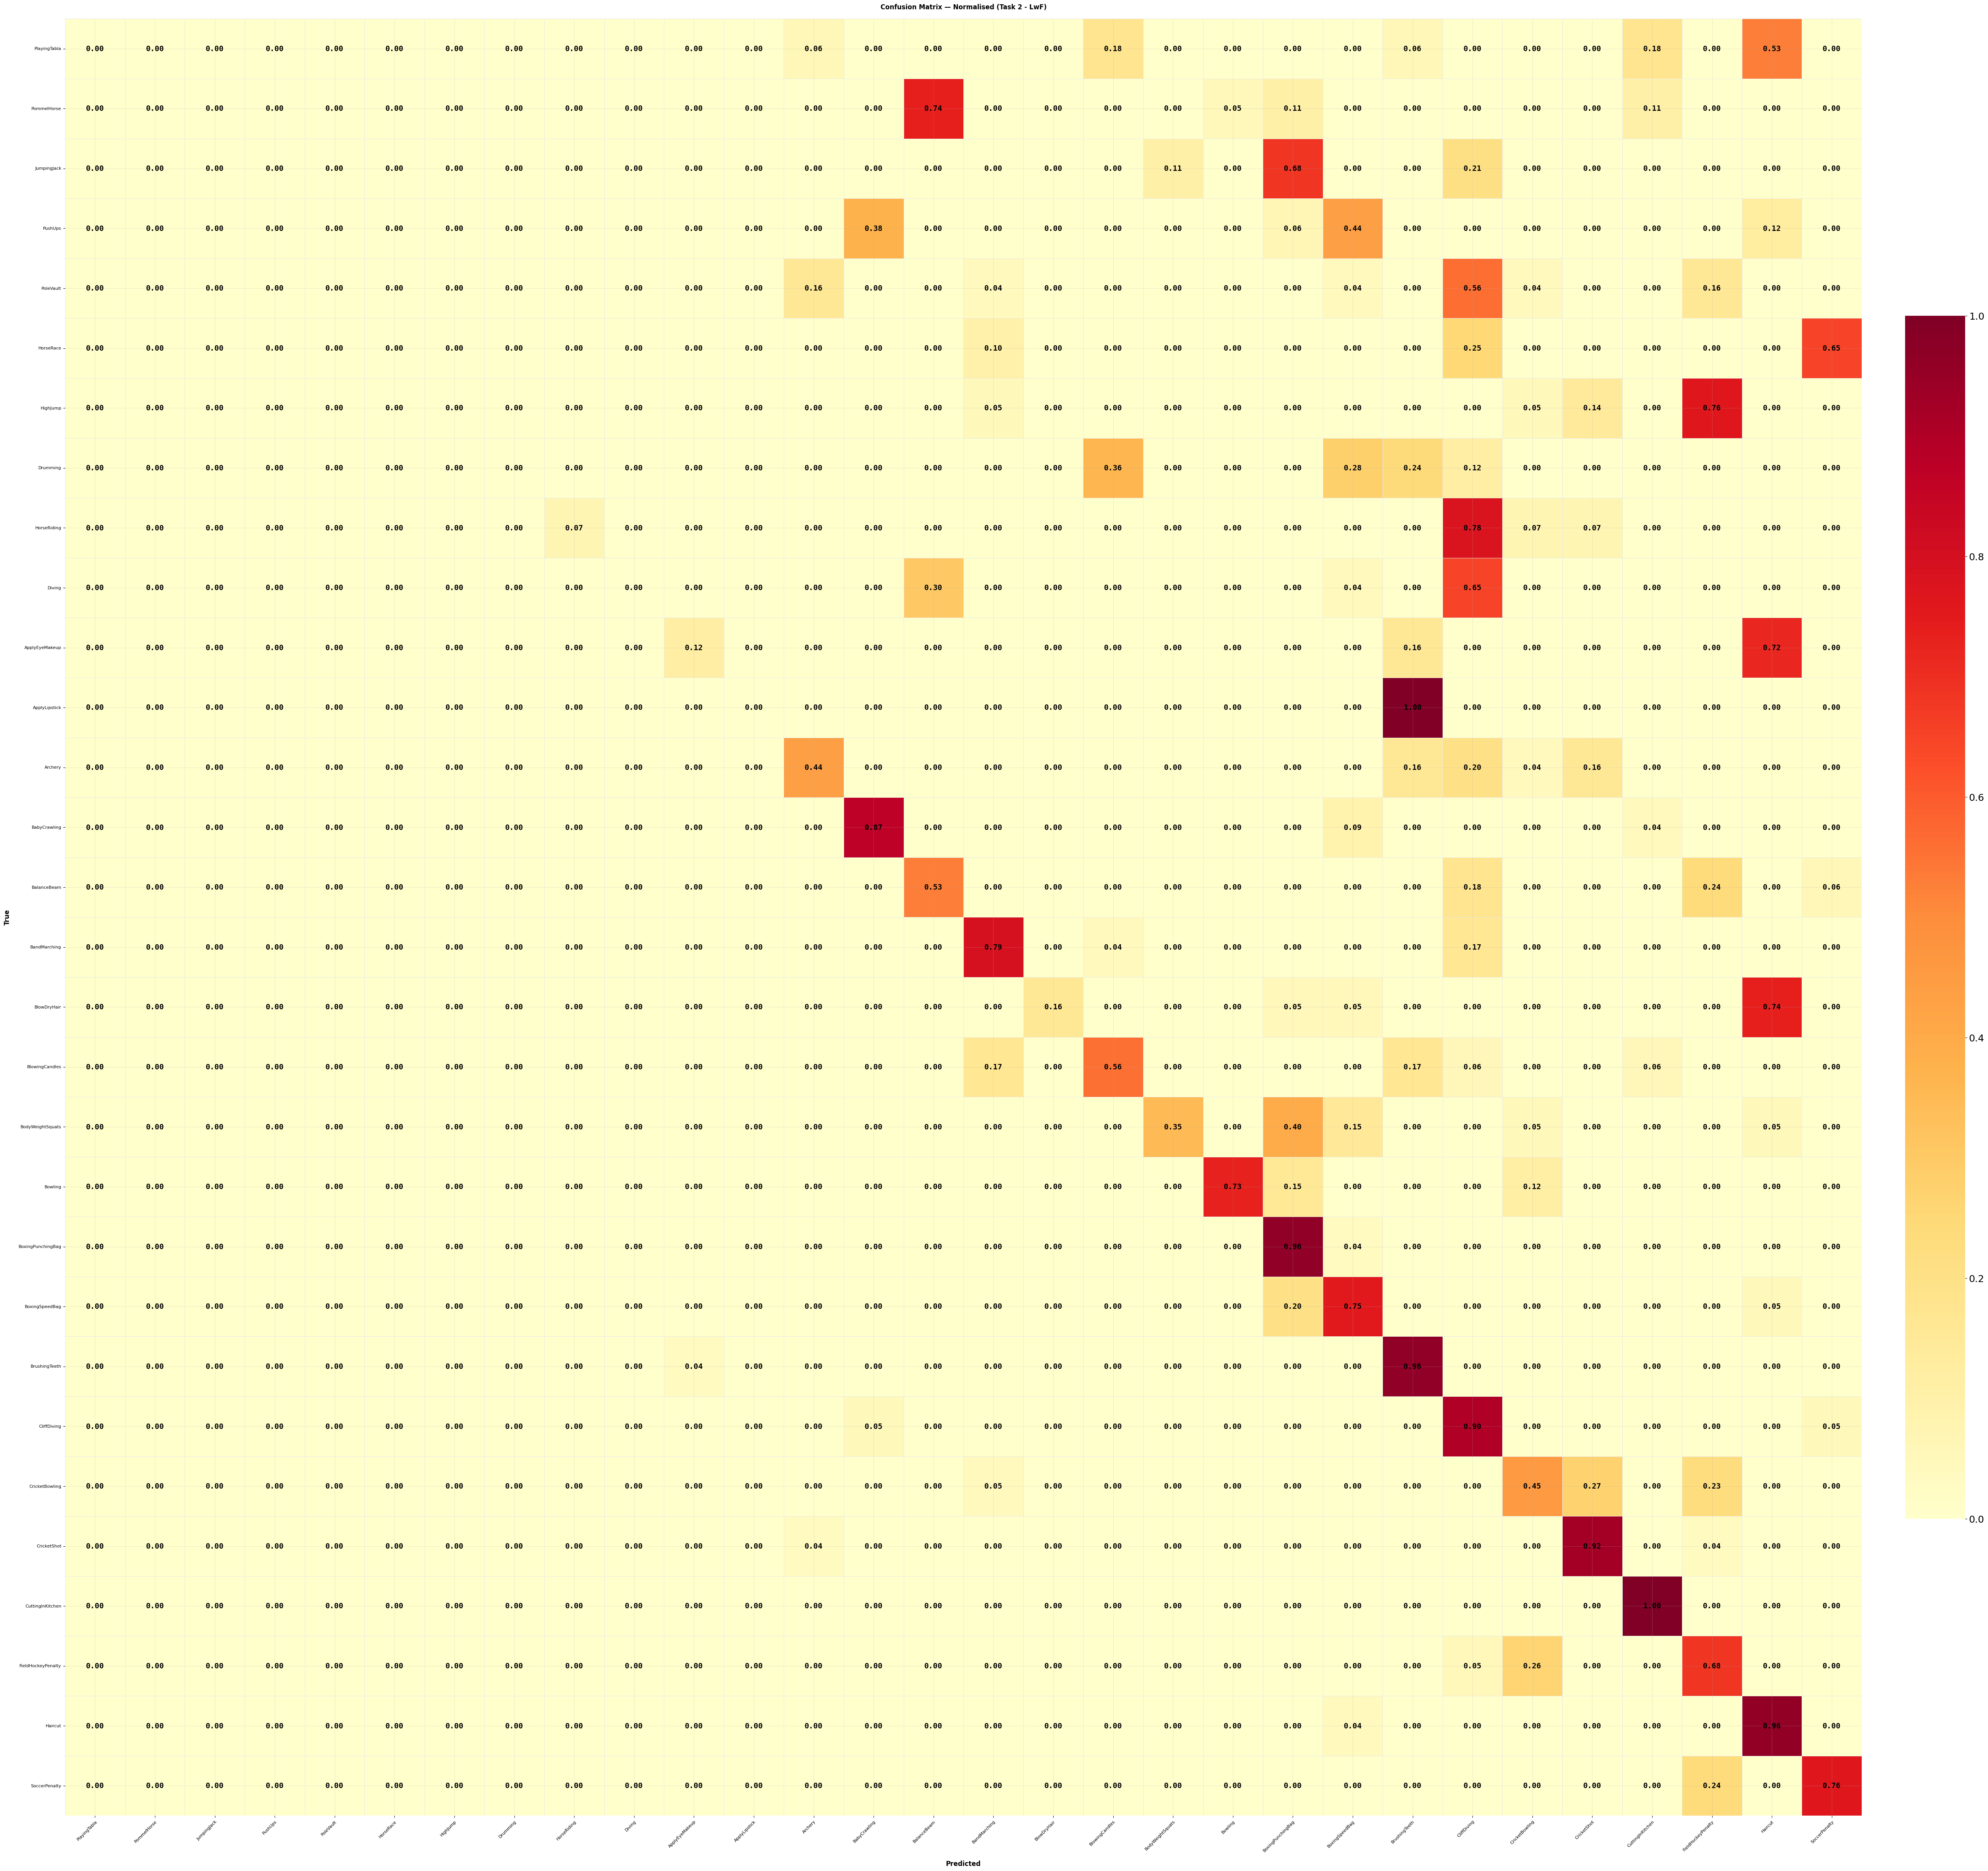

In [24]:
_, all_preds, all_labels = test_model(model_task2, combined_test_loader2, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 2 - {ARM_NAME}",
)

In [25]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),
)


METRICS FOR 30 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.4489
  Precision : 0.4060
  Recall    : 0.4489
  F1-Score  : 0.3601

PER-CLASS REPORT 
                    precision    recall  f1-score   support

      PlayingTabla       0.00      0.00      0.00        17
       PommelHorse       0.00      0.00      0.00        19
       JumpingJack       0.00      0.00      0.00        19
           PushUps       0.00      0.00      0.00        16
         PoleVault       0.00      0.00      0.00        25
         HorseRace       0.00      0.00      0.00        20
          HighJump       0.00      0.00      0.00        21
          Drumming       0.00      0.00      0.00        25
       HorseRiding       1.00      0.07      0.14        27
            Diving       0.00      0.00      0.00        23
    ApplyEyeMakeup       0.75      0.12      0.21        25
     ApplyLipstick       0.00      0.00      0.00        20
           Archery       0.65      0.44      0.52        25
     

## **Latent Space**

In [26]:
preds_emb, labels_emb = predict_head(head_task2, CACHE, [0, 1, 2], device)

res_emb = report_accuracy(preds_emb, labels_emb, TASK_CLASSES, TASK_NAMES, class_to_idx,
                          title=f"FINAL - EMBEDDINGS ({ARM_NAME})")


  FINAL - EMBEDDINGS (LwF)
  Base          0.94%   (212 clips, 10 classes)
  Task1        46.54%   (217 clips, 10 classes)
  Task2        84.51%   (226 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     44.89%   (655 clips, all classes)
  mean/task    44.00%


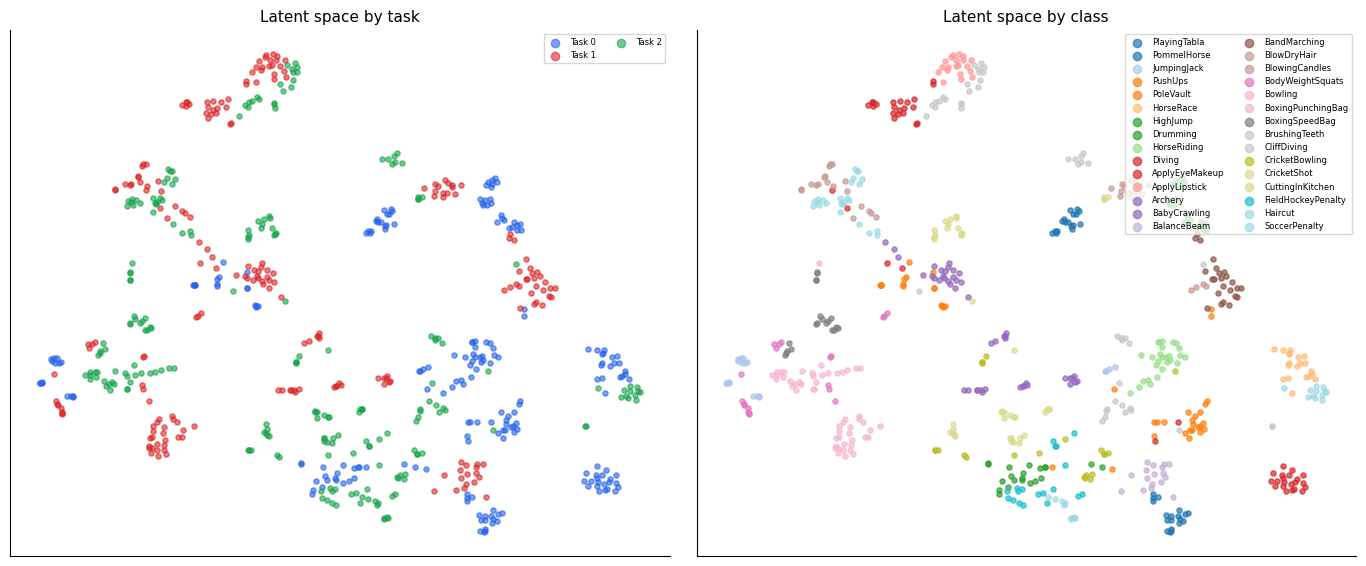

In [27]:
xy, lab = project_head_space(head_task2, CACHE, [0, 1, 2], device, seed=cfg.SEED)
task_of = {class_to_idx[c]: t for t, g in enumerate(TASK_CLASSES) for c in g}

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_latent_space(xy, lab, ALL_CLASSES_LIST, task_of=task_of,
                  title="Latent space by task", ax=ax[0])
plot_latent_space(xy, lab, ALL_CLASSES_LIST,
                  title="Latent space by class", ax=ax[1])
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/latent_{ARM_KEY}.png", dpi=150, bbox_inches="tight")
plt.show()

## **Evaluation on Real Images**

In [28]:
if not clips_available(TASK_ROOTS, "test"):
    print("Raw clips not found. Re-run the Preprocess cell to evaluate on real images.")
    res_real = None
else:
    backbone = load_frozen_backbone(
        device, ResNet50LSTMTeacher, cfg.RESNET50_PATH,
        hidden_size=cfg.TEACHER_HIDDEN, num_classes=len(cfg.SELECTED_CLASSES),
        dropout_p=cfg.DROPOUT_P, remap_fn=remap_teacher_checkpoint,
    )
    full_model = FullModel(backbone, head_task2, backbone_dim=cfg.BACKBONE_DIM).to(device)

    real_loader = clip_loaders(TASK_ROOTS, TASK_CLASSES, class_to_idx, "test",
                               batch_size=cfg.BATCH_SIZE, num_workers=cfg.NUM_WORKERS)[1]
    preds_real, labels_real = predict(full_model, real_loader, device)

    res_real = report_accuracy(preds_real, labels_real, TASK_CLASSES, TASK_NAMES,
                               class_to_idx, title=f"FINAL - REAL IMAGES ({ARM_NAME})")

  Dropped 53 num_batches_tracked buffer(s).

  FINAL - REAL IMAGES (LwF)
  Base         29.78%   (356 clips, 10 classes)
  Task1        41.67%   (360 clips, 10 classes)
  Task2        82.31%   (373 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     51.70%   (1089 clips, all classes)
  mean/task    51.25%


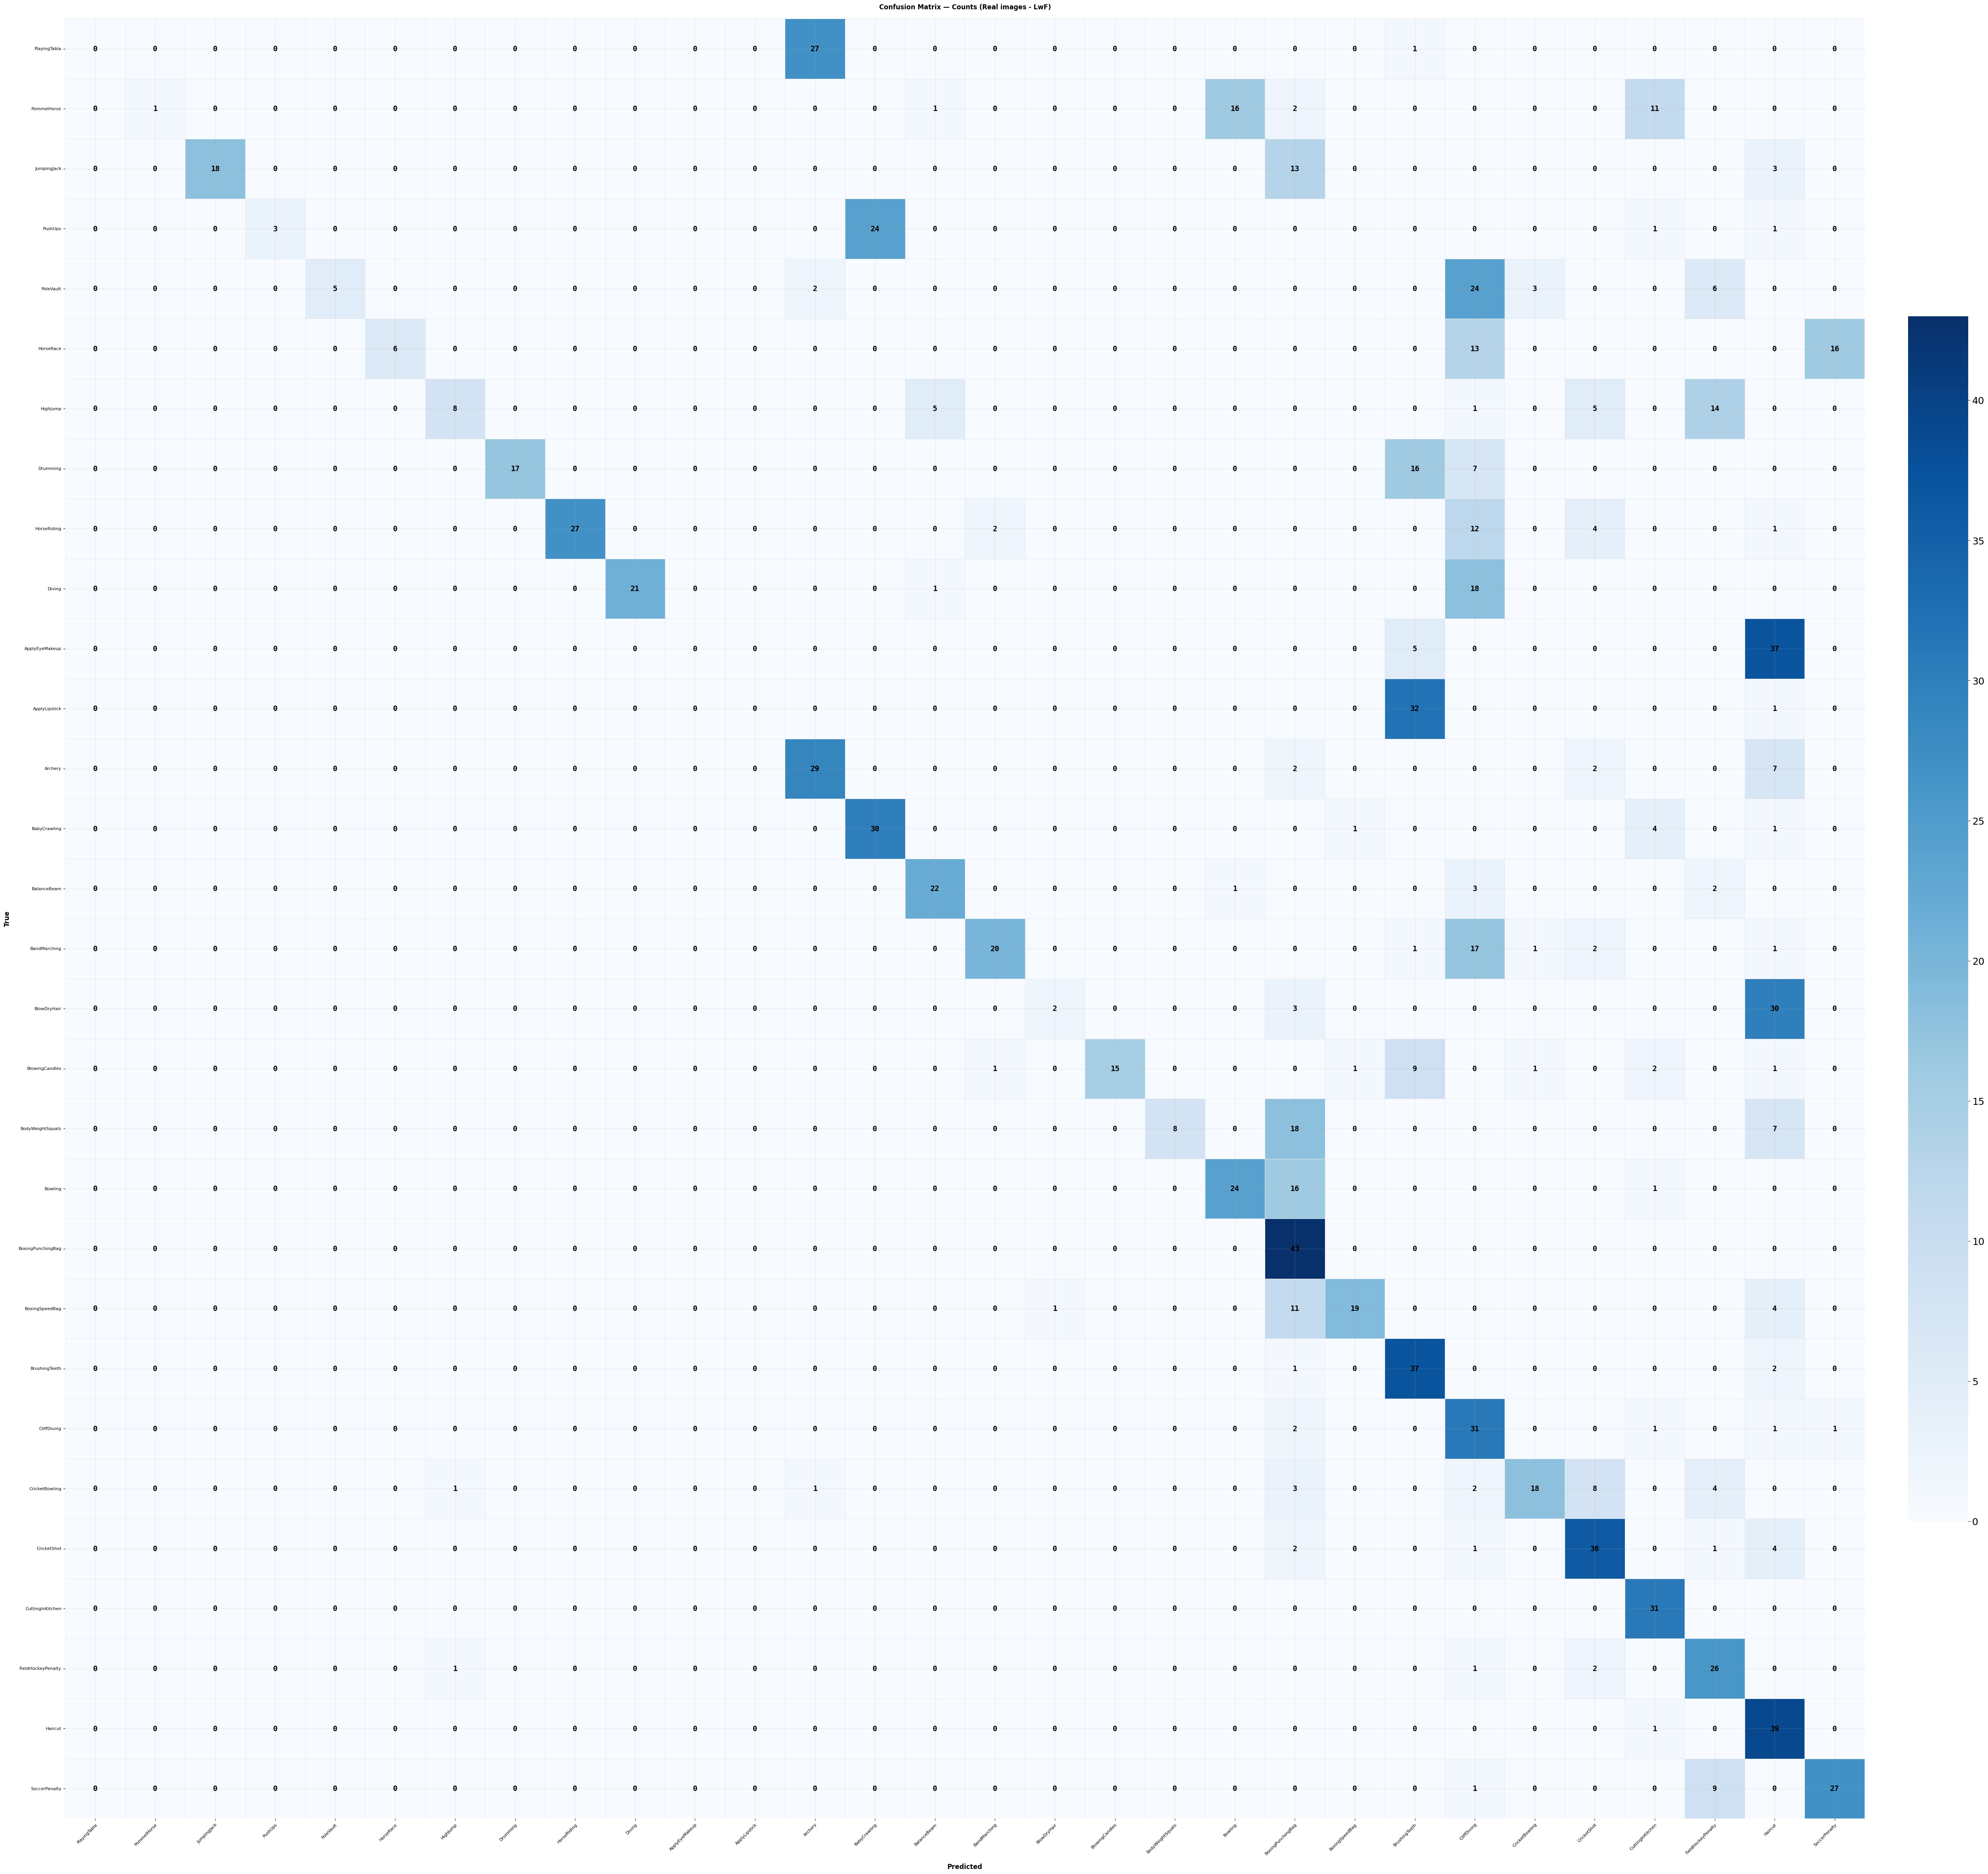

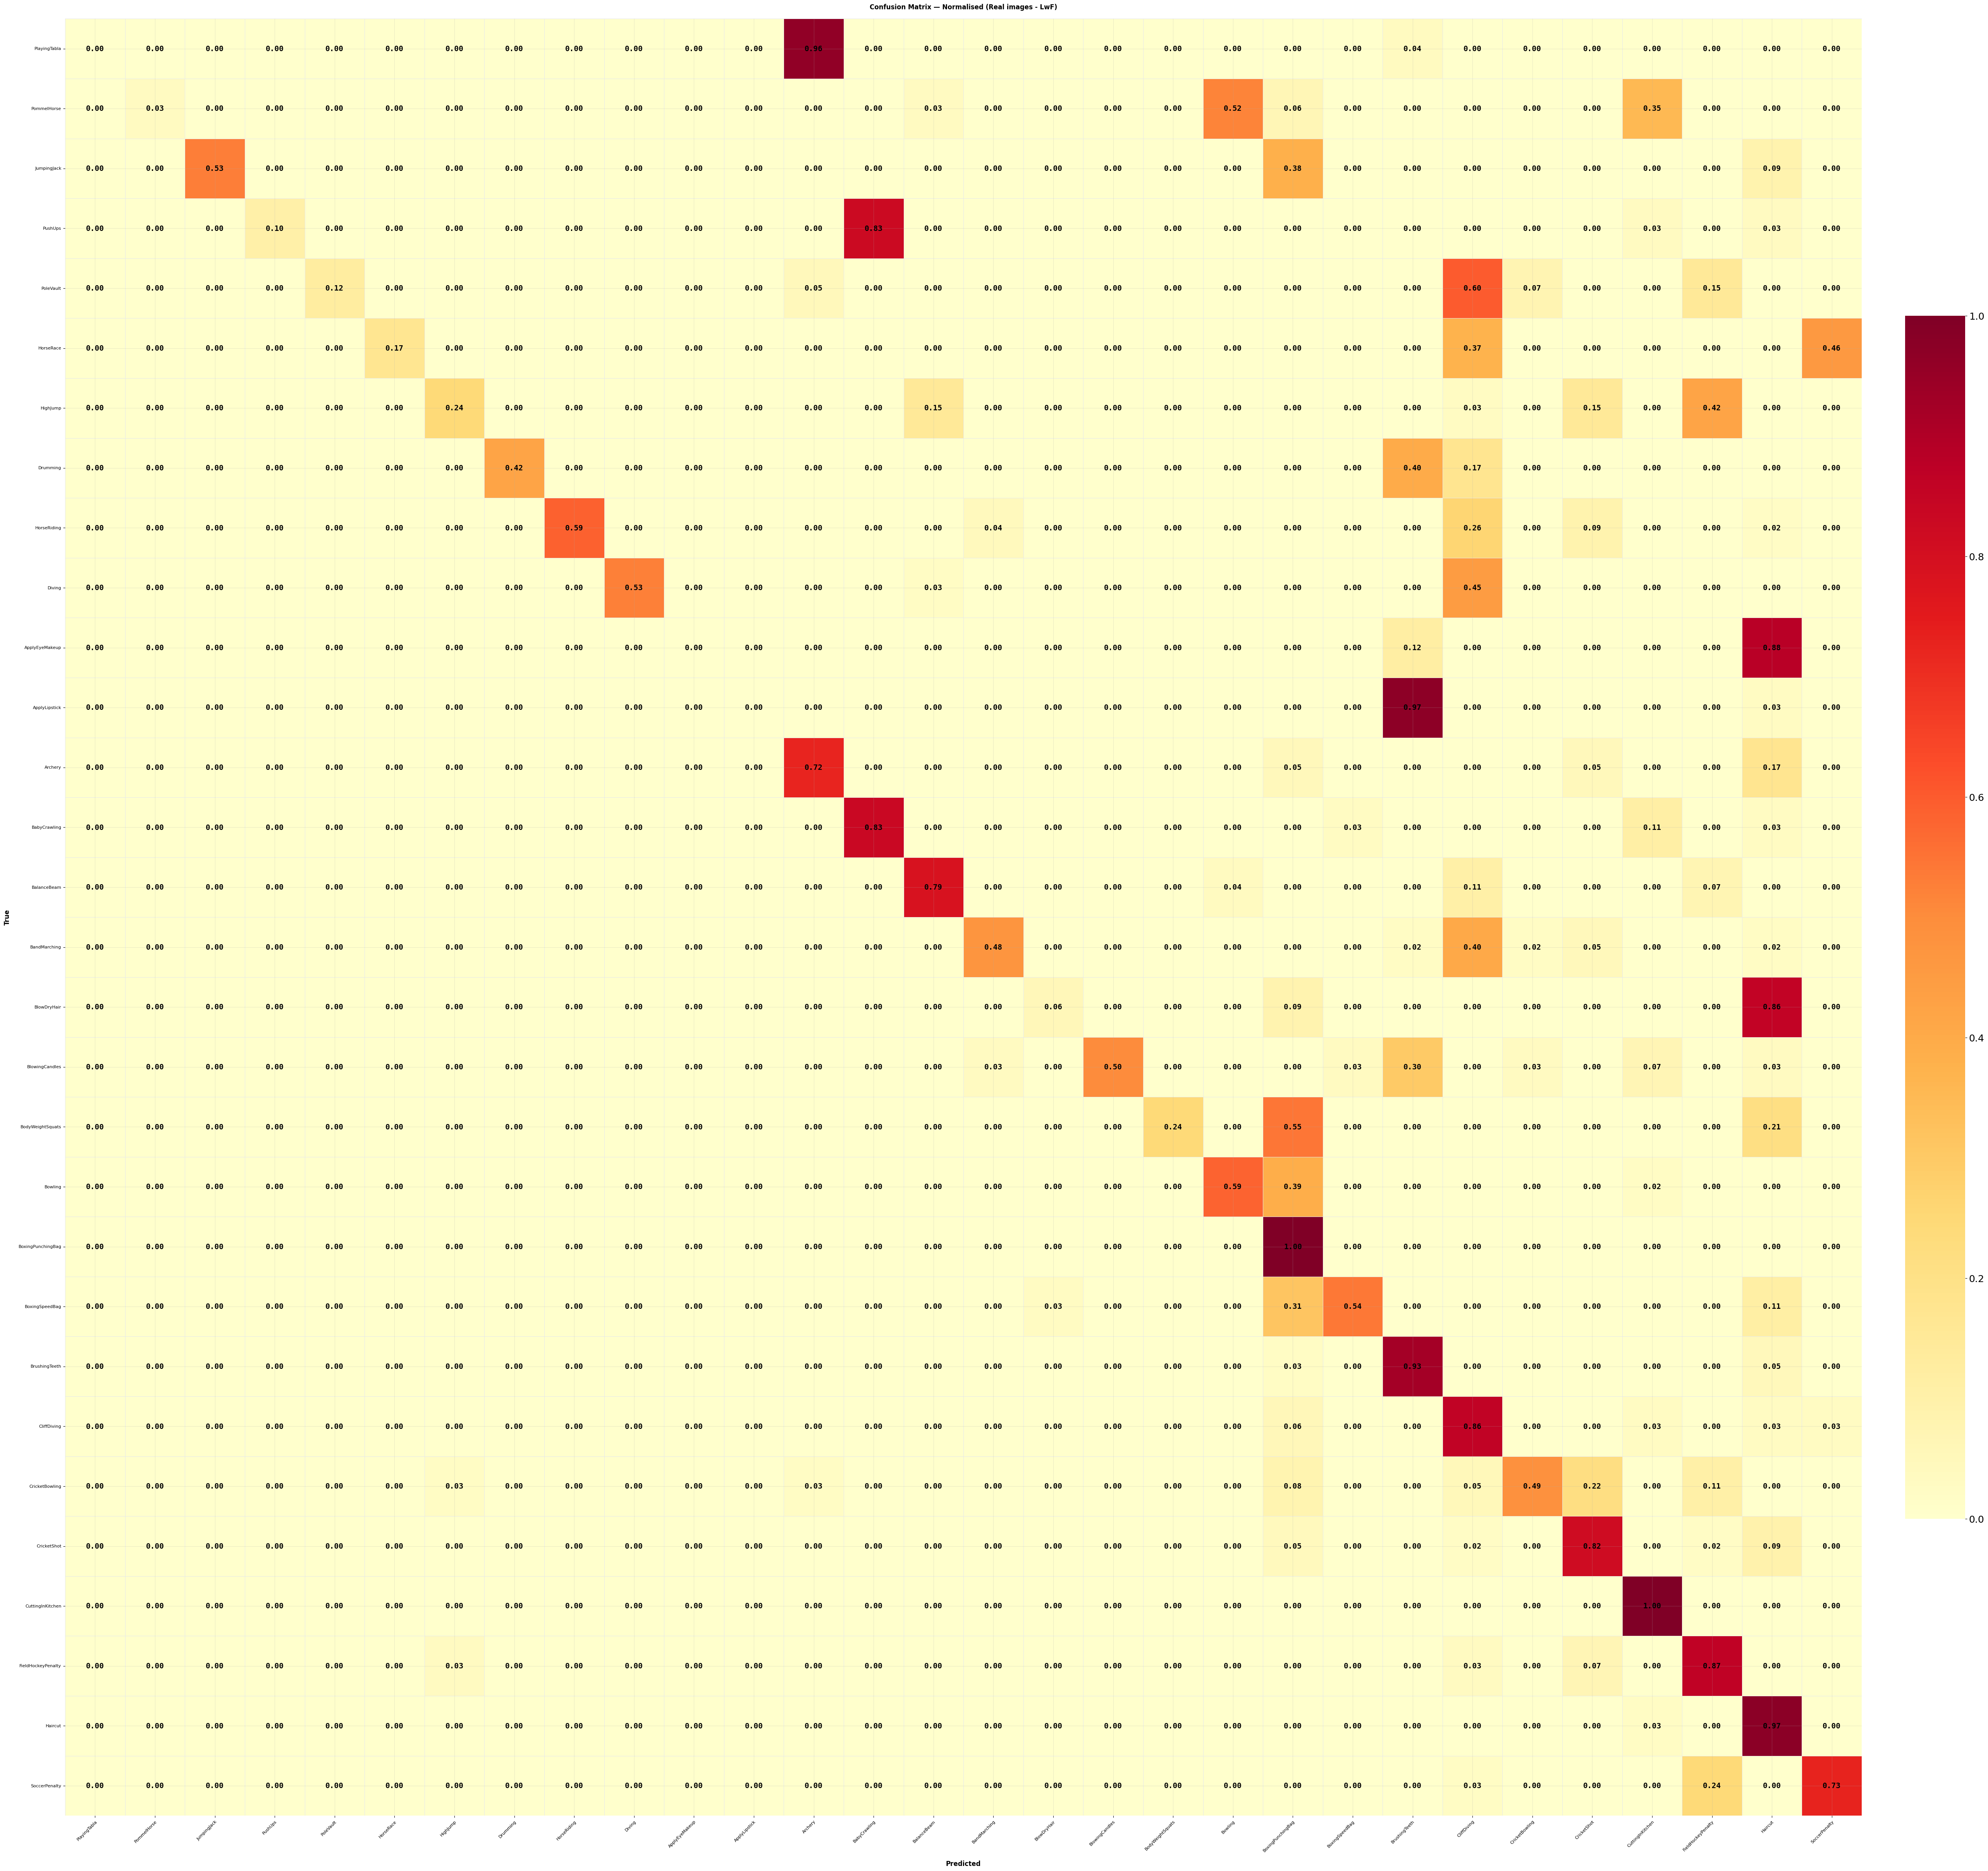


  EMBEDDINGS vs REAL IMAGES
  Split          embeddings   real images     diff
  ----------------------------------------------------------
  Base                0.94%        29.78%  +28.83%
  Task1              46.54%        41.67%   -4.88%
  Task2              84.51%        82.31%   -2.21%
  ----------------------------------------------------------
  COMBINED           44.89%        51.70%   +6.81%


In [29]:
if res_real is not None:
    plot_confusion_matrix(
        labels_real, preds_real,
        num_classes  = len(ALL_CLASSES_LIST),
        classes_list = ALL_CLASSES_LIST,
        name         = f"Real images - {ARM_NAME}",
    )

    compare_embeddings_vs_real(res_emb, res_real, TASK_NAMES)

## **Save**

In [ ]:
# per-task rows, captured before Task 2 mutates head_task1 in place
ROWS = [
    {0: eval_head(head_base, *task_split(CACHE, 0, "test"), device)},
    {0: results_after_t1["base"]["accuracy"],
     1: results_after_t1["task1_only"]["accuracy"]},
    {0: results_after_t2["base"]["accuracy"],
     1: results_after_t2["task1_only"]["accuracy"],
     2: results_after_t2["task2_only"]["accuracy"]},
]
BYTES_PER_CLASS = buffer_bytes_per_class(buffer, 15) if "buffer" in dir() else 0

R, m = save_arm_result(f"{cfg.RESULTS_DIR}/stage1_arm_{ARM_KEY}.json",
                       ARM_NAME, ROWS, TASK_NAMES, BYTES_PER_CLASS,
                       config=ARM_CONFIG, ceiling=None)
cl_report(R, ARM_NAME, TASK_NAMES)
torch.save(head_task2.state_dict(), f"{cfg.CKPT_DIR}/head_{ARM_KEY}.pt")

with open(f"{cfg.RESULTS_DIR}/stage1_final_{ARM_KEY}.json", "w") as f:
    json.dump({"embeddings": res_emb, "real_images": res_real}, f, indent=2, default=float)